In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("cleaned_preprocessed_disaster_data.csv")

df.head()

,iso3,country,disaster_type,year,deaths,affected,mng_cap,inventory,distance,priority_tier
0,BRA,Brazil,Flood,2018,4.0,250.0,4.247241,1664,120,Moderate
1,USA,United States of America,Wildfire,2002,0.0,1572.0,7.704286,1817,218,Low
2,RWA,Rwanda,Flood,2022,3.0,0.0,6.391964,662,448,Moderate
3,USA,United States of America,Drought,2024,0.0,0.0,5.591951,211,187,Critical
4,IDN,Indonesia,Road,2022,10.0,20.0,2.936112,705,434,Critical


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16752 entries, 0 to 16751
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   iso3           16752 non-null  object 
 1   country        16752 non-null  object 
 2   disaster_type  16752 non-null  object 
 3   year           16752 non-null  int64  
 4   deaths         16752 non-null  float64
 5   affected       16752 non-null  float64
 6   mng_cap        16752 non-null  float64
 7   inventory      16752 non-null  int64  
 8   distance       16752 non-null  int64  
 9   priority_tier  16752 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 1.3+ MB


,0
iso3,0
country,0
disaster_type,0
year,0
deaths,0
affected,0
mng_cap,0
inventory,0
distance,0
priority_tier,0


In [4]:
le_iso = LabelEncoder()
le_country = LabelEncoder()
le_disaster = LabelEncoder()
le_priority = LabelEncoder()

df['iso3'] = le_iso.fit_transform(df['iso3'])
df['country'] = le_country.fit_transform(df['country'])
df['disaster_type'] = le_disaster.fit_transform(df['disaster_type'])

df['priority_tier'] = le_priority.fit_transform(df['priority_tier'])

In [5]:
X = df.drop("priority_tier", axis=1)
y = df["priority_tier"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [8]:
y_pred = model.predict(X_test)

In [9]:
probabilities = model.predict_proba(X_test)
print(probabilities[:5])

[[9.95677991e-01 4.76190476e-04 3.84581807e-03]
 [9.90008066e-01 1.56750710e-04 9.83518352e-03]
 [2.02898551e-03 9.60129660e-01 3.78413548e-02]
 [3.43433449e-01 2.15124883e-02 6.35054062e-01]
 [1.44164664e-02 8.36075539e-01 1.49507994e-01]]


In [10]:
print(model.classes_)
print(le_priority.classes_)

[0 1 2]
['Critical' 'Low' 'Moderate']


In [11]:
def adjust_priority(prob):

    critical_prob = prob[0]
    low_prob = prob[1]
    moderate_prob = prob[2]

    if critical_prob > 0.85:
        return 0
    elif moderate_prob > 0.50:
        return 2
    else:
        return 1

In [12]:
adjusted_pred = [adjust_priority(p) for p in probabilities]

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [14]:
standard_acc = accuracy_score(y_test, y_pred)
adjusted_acc = accuracy_score(y_test, adjusted_pred)

print(f"Standard Model Accuracy: {standard_acc:.2%}")
print(f"Adjusted Logic Accuracy: {adjusted_acc:.2%}")

Standard Model Accuracy: 98.06%
Adjusted Logic Accuracy: 92.03%


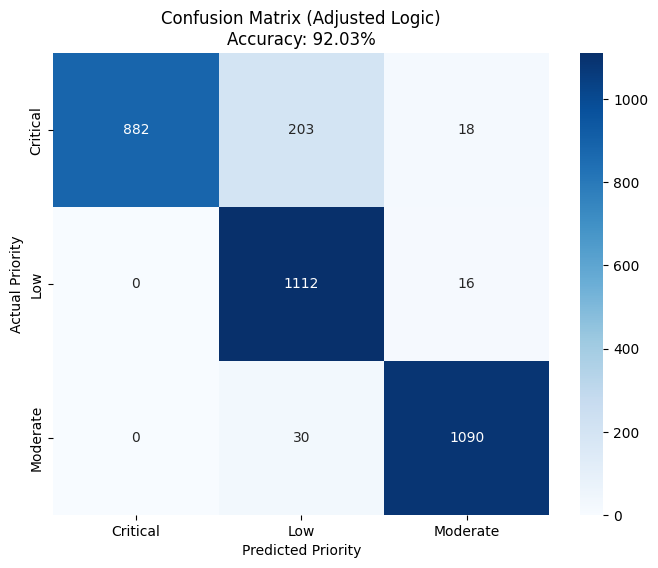

In [15]:
cm = confusion_matrix(y_test, adjusted_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_priority.classes_,
            yticklabels=le_priority.classes_)

plt.title(f'Confusion Matrix (Adjusted Logic)\nAccuracy: {adjusted_acc:.2%}')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.show()

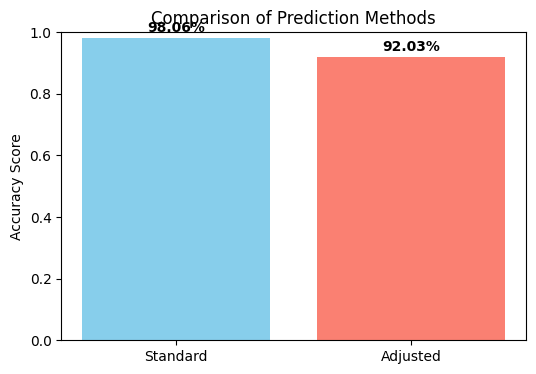

In [16]:
plt.figure(figsize=(6, 4))
plt.bar(['Standard', 'Adjusted'], [standard_acc, adjusted_acc], color=['skyblue', 'salmon'])
plt.ylabel('Accuracy Score')
plt.title('Comparison of Prediction Methods')
plt.ylim(0, 1) # Set y-axis from 0 to 100%
for i, v in enumerate([standard_acc, adjusted_acc]):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')
plt.show()